# Step 1: Extract all symbols from all the images in data/raw/easy folder

# Preprocessing Pipeline — batch symbol extraction

Processes every image in `data/raw/easy/`, extracts individual symbol crops,
and saves them to `data/segments/unlabeled/`.

**Incremental-safe:** crops are named `{image_stem}_{idx:04d}.png`.  
Before saving a crop the script checks whether that filename already exists
in `unlabeled/` or in any `labeled/<class>/` folder.  
If it does, the crop is skipped — so you can add new images at any time
and re-run without disturbing crops you already labelled.

Run order:
1. Run this notebook → new crops appear in `data/segments/unlabeled/`
2. Run `labeler.py` → label new crops (they move to `labeled/<class>/`)
3. Add more images → re-run this notebook → only new crops queued


In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── Paths ─────────────────────────────────────────────────────────────────
RAW_DIR        = Path("data/raw/easy")
UNLABELED_DIR  = Path("data/segments/unlabeled")
LABELED_DIR    = Path("data/segments/labeled")
UNLABELED_DIR.mkdir(parents=True, exist_ok=True)

# ── Tuning knobs ──────────────────────────────────────────────────────────
PADDING        = 6     # px of padding added around each contour bbox
CROP_SIZE      = (64, 64)
DENOISE_H      = 20    # fastNlMeansDenoising strength
THRESH_BLOCK   = 19    # adaptiveThreshold block size
THRESH_C       = 4     # adaptiveThreshold constant
MIN_CONTOUR_AREA     = 60    # discard specks smaller than this
MAX_CONTOUR_AREA_FRAC = 0.15  # discard blobs larger than 15% of ROI area

print(f"Raw images : {RAW_DIR}")
print(f"Unlabeled  : {UNLABELED_DIR}")
print(f"Labeled    : {LABELED_DIR}")


Raw images : data/raw/easy
Unlabeled  : data/segments/unlabeled
Labeled    : data/segments/labeled


In [2]:
# ── Step 1 : load + basic pre-processing ──────────────────────────────────
def preprocess(img_bgr: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns (img_bgr, denoised_gray, binary).

    denoised_gray is used for crop extraction — crops must come from the
    same denoised image that the classifier will see at inference time so
    that training and production data look identical.
    binary has ink=255, background=0 and is used for ROI + contour detection.
    """
    gray     = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    denoised = cv.fastNlMeansDenoising(gray, h=DENOISE_H,
                                        templateWindowSize=7,
                                        searchWindowSize=21)
    binary   = cv.adaptiveThreshold(
        denoised, 255,
        cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV,
        blockSize=THRESH_BLOCK, C=THRESH_C,
    )
    # Remove tiny noise
    k1 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (2, 2))
    binary = cv.morphologyEx(binary, cv.MORPH_OPEN,  k1, iterations=1)
    # Close small gaps inside symbols
    k2 = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3, 3))
    binary = cv.morphologyEx(binary, cv.MORPH_CLOSE, k2, iterations=1)
    return img_bgr, denoised, binary


# ── Step 2 : ROI detection ─────────────────────────────────────────────────
def find_roi(binary: np.ndarray, margin_frac: float = 0.02) -> tuple[int,int,int,int]:
    """Return (x, y, w, h) bounding box of the stitch region."""
    k       = cv.getStructuringElement(cv.MORPH_RECT, (30, 20))
    dilated = cv.dilate(binary, k, iterations=3)
    contours, _ = cv.findContours(dilated, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not contours:
        h, w = binary.shape
        return 0, 0, w, h
    largest  = max(contours, key=cv.contourArea)
    x, y, w, h = cv.boundingRect(largest)
    H, W     = binary.shape
    mx, my   = int(W * margin_frac), int(H * margin_frac)
    x = max(0, x - mx);  y = max(0, y - my)
    w = min(W - x, w + 2*mx)
    h = min(H - y, h + 2*my)
    return x, y, w, h


# ── Step 3 : contour extraction + filtering ────────────────────────────────
def extract_contours(roi_bin: np.ndarray) -> list:
    """
    Find symbol contours, remove nested and out-of-range ones.
    Returns a filtered list of contours sorted top-left → bottom-right.
    """
    roi_area = roi_bin.shape[0] * roi_bin.shape[1]
    max_area = roi_area * MAX_CONTOUR_AREA_FRAC

    raw, _ = cv.findContours(roi_bin, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)

    # Area filter
    filtered = [c for c in raw
                if MIN_CONTOUR_AREA <= cv.contourArea(c) <= max_area]

    # Nesting filter: if a bbox is completely inside another, keep only the outer one
    rects = [cv.boundingRect(c) for c in filtered]

    def inside(r1, r2):
        x1,y1,w1,h1 = r1;  x2,y2,w2,h2 = r2
        return x1>=x2 and y1>=y2 and x1+w1<=x2+w2 and y1+h1<=y2+h2

    by_area = sorted(range(len(filtered)),
                     key=lambda i: rects[i][2]*rects[i][3], reverse=True)
    keep = []
    for i in by_area:
        if not any(inside(rects[i], rects[j]) for j in keep):
            keep.append(i)

    result = [filtered[i] for i in keep]
    # Sort top-left → bottom-right (row-major)
    result.sort(key=lambda c: (cv.boundingRect(c)[1], cv.boundingRect(c)[0]))
    return result


# ── Step 4 : crop extraction ───────────────────────────────────────────────
def extract_crops(roi_gray: np.ndarray, contours: list,
                   padding: int = PADDING) -> list[dict]:
    """
    Return list of dicts: {crop, bbox, idx}.
    crop is a CROP_SIZE grayscale uint8 array.
    """
    H, W = roi_gray.shape
    crops = []
    for idx, c in enumerate(contours):
        x, y, w, h = cv.boundingRect(c)
        x1 = max(x - padding, 0);  y1 = max(y - padding, 0)
        x2 = min(x + w + padding, W);  y2 = min(y + h + padding, H)
        patch = roi_gray[y1:y2, x1:x2]
        patch = cv.resize(patch, CROP_SIZE, interpolation=cv.INTER_AREA)
        crops.append(dict(crop=patch, bbox=(x, y, w, h), idx=idx))
    return crops


print("Helper functions defined.")


Helper functions defined.


In [3]:
# Build a set of ALL crop filenames that already exist (labeled or unlabeled).
# A crop whose filename is in this set will not be saved again, so previously
# labelled work is never overwritten and never re-queued.

def build_existing_set() -> set[str]:
    existing = set()
    for p in UNLABELED_DIR.glob("*.png"):
        existing.add(p.name)
    if LABELED_DIR.exists():
        for p in LABELED_DIR.glob("**/*.png"):
            existing.add(p.name)
    return existing

existing_crops = build_existing_set()
print(f"Already-existing crops: {len(existing_crops)}")
print(f"  unlabeled : {len(list(UNLABELED_DIR.glob('*.png')))}")
labeled_total = len(list(LABELED_DIR.glob('**/*.png'))) if LABELED_DIR.exists() else 0
print(f"  labeled   : {labeled_total}")


Already-existing crops: 1796
  unlabeled : 216
  labeled   : 1580


In [4]:
image_paths = sorted(RAW_DIR.glob("*.png")) + sorted(RAW_DIR.glob("*.jpg"))
print(f"Found {len(image_paths)} image(s) in {RAW_DIR}\n")

summary = []   # (stem, total_contours, new_saved, skipped)

for img_path in image_paths:
    stem = img_path.stem
    img_bgr = cv.imread(str(img_path))
    if img_bgr is None:
        print(f"  ⚠ Cannot read {img_path.name} — skipping")
        continue

    # ── Pre-process ───────────────────────────────────────────────────────
    img_bgr, denoised_gray, binary = preprocess(img_bgr)

    # ── ROI ───────────────────────────────────────────────────────────────
    roi_x, roi_y, roi_w, roi_h = find_roi(binary)
    roi_bin  = binary[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
    # Use denoised_gray — crops must match the denoised input the classifier
    # was trained on. Using the original noisy image here would cause a
    # train/inference mismatch.
    roi_gray = denoised_gray[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]

    # ── Contours ──────────────────────────────────────────────────────────
    contours = extract_contours(roi_bin)
    crops    = extract_crops(roi_gray, contours)

    # ── Save (incremental — skip existing) ────────────────────────────────
    new_saved = 0
    skipped   = 0
    for item in crops:
        fname = f"{stem}_{item['idx']:04d}.png"
        if fname in existing_crops:
            skipped += 1
        else:
            cv.imwrite(str(UNLABELED_DIR / fname), item['crop'])
            existing_crops.add(fname)   # prevent duplicate within this run
            new_saved += 1

    summary.append((stem, len(contours), new_saved, skipped))
    status = f"  {new_saved} new" + (f", {skipped} skipped" if skipped else "")
    print(f"  {img_path.name:30s}  {len(contours):3d} symbols{status}")

# ── Summary ───────────────────────────────────────────────────────────────
total_new     = sum(r[2] for r in summary)
total_skipped = sum(r[3] for r in summary)
print(f"\n{'─'*55}")
print(f"Total new crops saved : {total_new}")
print(f"Total skipped (exist) : {total_skipped}")
print(f"Unlabeled queue now   : {len(list(UNLABELED_DIR.glob('*.png')))}")


Found 11 image(s) in data/raw/easy

  2.png                           302 symbols  0 new, 302 skipped
  5.png                           182 symbols  0 new, 182 skipped
  6.png                           252 symbols  0 new, 252 skipped
  1.jpg                            45 symbols  0 new, 45 skipped
  10.jpg                          229 symbols  229 new
  11.jpg                          419 symbols  419 new
  3.jpg                           237 symbols  0 new, 237 skipped
  4.jpg                           516 symbols  349 new, 167 skipped
  7.jpg                           156 symbols  156 new
  8.jpg                            46 symbols  46 new
  9.jpg                           123 symbols  123 new

───────────────────────────────────────────────────────
Total new crops saved : 1322
Total skipped (exist) : 1185
Unlabeled queue now   : 1538


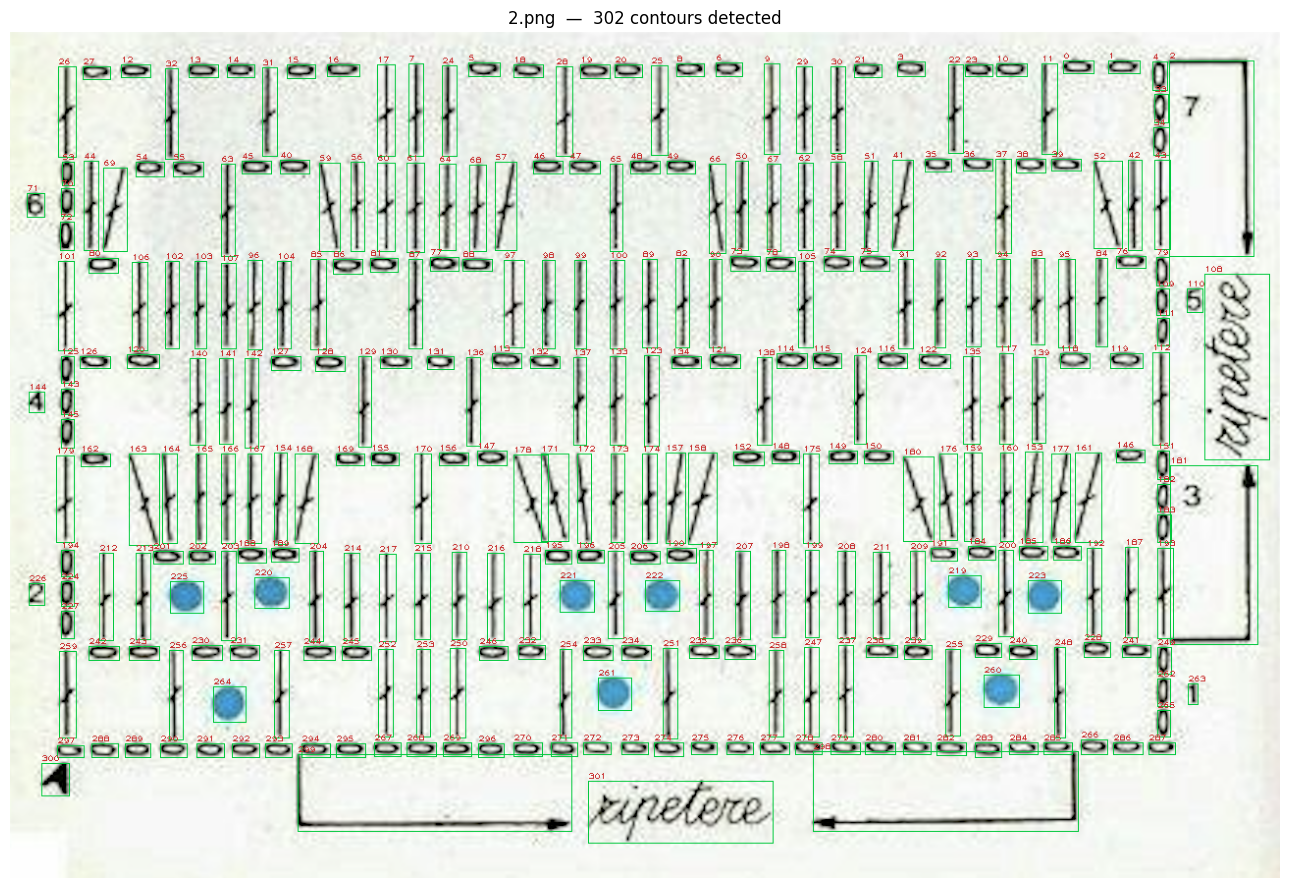

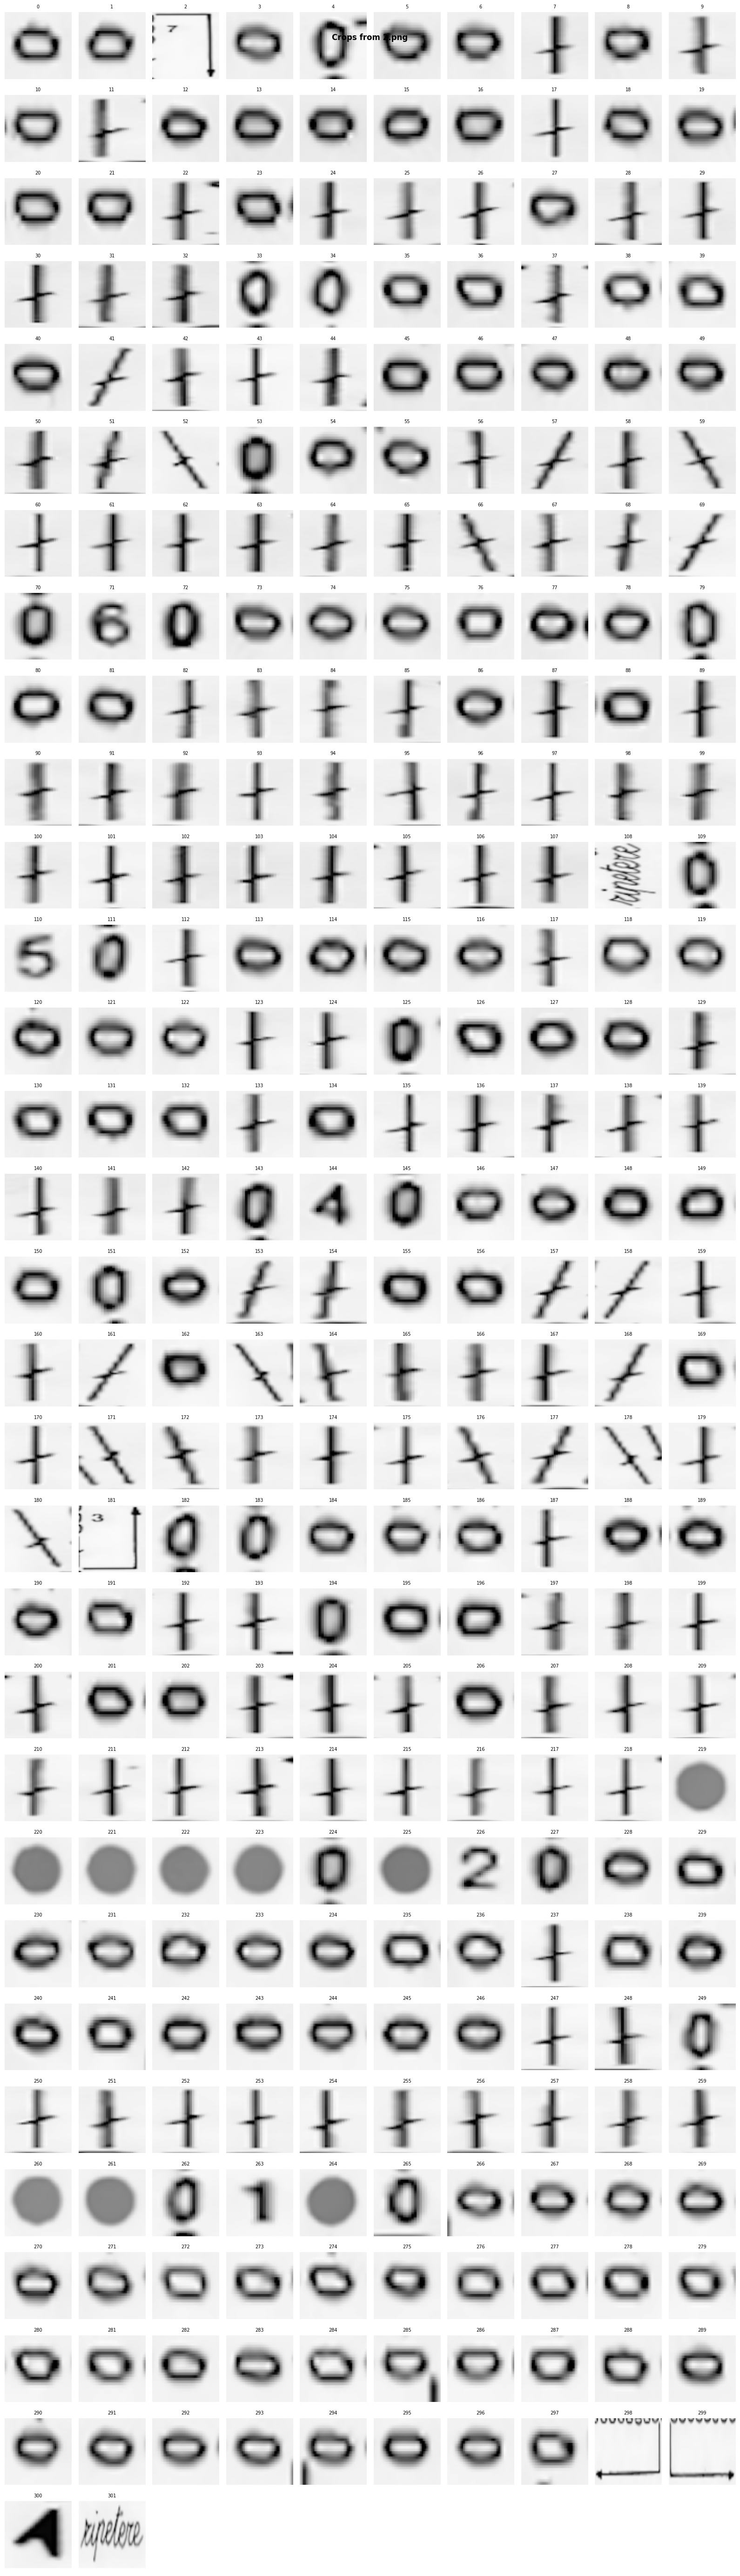

In [5]:
# ── Optional: visualise contour detection for a single image ──────────────
INSPECT_IMAGE = sorted(RAW_DIR.glob("*.png"))[0]   # change to any image

img_bgr = cv.imread(str(INSPECT_IMAGE))
img_bgr, denoised_gray, binary = preprocess(img_bgr)
roi_x, roi_y, roi_w, roi_h = find_roi(binary)
roi_bin  = binary[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
roi_gray = denoised_gray[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w]
roi_rgb  = cv.cvtColor(
    img_bgr[roi_y:roi_y+roi_h, roi_x:roi_x+roi_w],
    cv.COLOR_BGR2RGB)
contours = extract_contours(roi_bin)

vis = roi_rgb.copy()
for i, c in enumerate(contours):
    x, y, w, h = cv.boundingRect(c)
    cv.rectangle(vis, (x, y), (x+w, y+h), (0, 200, 60), 1)
    cv.putText(vis, str(i), (x, max(0, y-2)),
               cv.FONT_HERSHEY_PLAIN, 0.6, (200, 50, 50), 1)

plt.figure(figsize=(13, 9))
plt.imshow(vis)
plt.title(f"{INSPECT_IMAGE.name}  —  {len(contours)} contours detected")
plt.axis("off")
plt.tight_layout()
plt.show()

# Show the extracted crops as a grid
crops = extract_crops(roi_gray, contours)
cols_g = 10
rows_g = max(1, (len(crops) + cols_g - 1) // cols_g)
fig, axes = plt.subplots(rows_g, cols_g, figsize=(cols_g*1.6, rows_g*1.8))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for ax, item in zip(axes, crops):
    ax.imshow(item['crop'], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f"{item['idx']}", fontsize=7)
    ax.axis('off')
for ax in axes[len(crops):]:
    ax.axis('off')
plt.suptitle(f"Crops from {INSPECT_IMAGE.name}", fontweight='bold')
plt.tight_layout()
plt.show()
